In [ ]:
import os
import copy
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"edersondacosta","key":"33d8c9bc05e847b306e10ee0b54b9883"}'}

In [ ]:
!mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:12<00:00, 196MB/s]



In [ ]:
!unzip -q chest-xray-pneumonia.zip

replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: All


In [ ]:
print(os.listdir('/content/chest_xray'))

['chest_xray', 'test', 'train', '__MACOSX', 'val']


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root='/content/chest_xray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='/content/chest_xray/train',
    transform=test_transform
)

In [ ]:
test_dataset = datasets.ImageFolder(
    root='/content/chest_xray/test',
    transform=test_transform
)

In [ ]:
print(train_dataset.classes)

['NORMAL', 'PNEUMONIA']


In [ ]:
#Divisão Treino e Validação

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

indices = list(range(len(train_dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=train_dataset.targets
)

train_dataset = Subset(
    train_dataset,
    train_indices
)

val_dataset = Subset(
    val_dataset,
    val_indices
)

In [ ]:
#DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
#Arquitetura CNN Baseline

class PneumoniaCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256*14*14,512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512,128),
            nn.ReLU(),

            nn.Linear(128,2)

        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
#Criando o modelo

model = PneumoniaCNN().to(device)

In [ ]:
#Função de Perda

criterion = nn.CrossEntropyLoss()

In [ ]:
#Otimizador - ADAM

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
#Épocas

NUM_EPOCHS = 30

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/pneumonia/Experimento_2"

os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import copy

best_val_loss = float('inf')
patience = 10
counter = 0

best_model_wts = copy.deepcopy(model.state_dict())

start_epoch = 0
start_epoch = 0

In [ ]:
#Armazenar as métricas nas variáveis

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [ ]:
checkpoint_path = os.path.join(SAVE_DIR, "checkpoint.pth")

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    #Salvando o Histórico
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])

    train_accs = checkpoint.get('train_accs', [])
    val_accs = checkpoint.get('val_accs', [])

    model.load_state_dict(
    checkpoint['model_state_dict']
    )



    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    start_epoch = checkpoint['epoch'] + 1

    best_val_loss = checkpoint['best_val_loss']

    print(f"Treinamento retomado da época {start_epoch}")

else:

    print("Iniciando treinamento do zero")

Iniciando treinamento do zero


In [ ]:
print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

print(len(train_loader))
print(len(val_loader))

Treino: 4172
Validação: 1044
Teste: 624
66
17


In [ ]:
# TREINAMENTO

NUM_EPOCHS = 30

for epoch in range(start_epoch, NUM_EPOCHS):





    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #############################
    # VALIDAÇÃO
    #############################

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f'Epoch [{epoch+1}/{NUM_EPOCHS}] | '
        f'Train Loss={train_loss:.10f} | '
        f'Val Loss={val_loss:.10f} | '
        f'Train Acc={train_acc:.10f} | '
        f'Val Acc={val_acc:.10f}'
    )

    ###################################
    # SALVAR CHECKPOINT
    ###################################

    checkpoint = {

    'epoch': epoch,

    'model_state_dict': model.state_dict(),

    'optimizer_state_dict': optimizer.state_dict(),

    'best_val_loss': best_val_loss,

    'train_losses': train_losses,

    'val_losses': val_losses,

    'train_accs': train_accs,

    'val_accs': val_accs

}


    torch.save(
        checkpoint,
        os.path.join(
            SAVE_DIR,
            "checkpoint.pth"
        )
    )

    ###################################
    # MELHOR MODELO
    ###################################

    if val_loss < best_val_loss:

      best_val_loss = val_loss

      best_model_wts = copy.deepcopy(
          model.state_dict()
      )

      torch.save(
          model.state_dict(),
          os.path.join(
              SAVE_DIR,
              "best_model.pth"
          )
      )

      counter = 0

      print(
          f"Melhor modelo salvo! "
          f"Val Loss = {val_loss:.4f}"
      )

    else:

        counter += 1

        print(
            f"Sem melhora ({counter}/{patience})"
        )

        if counter >= patience:

            print("Early Stopping")

            break

Epoch [1/30] | Train Loss=0.5780011695 | Val Loss=0.4950979615 | Train Acc=0.7351390221 | Val Acc=0.7432950192
Melhor modelo salvo! Val Loss = 0.4951
Epoch [2/30] | Train Loss=0.3060640914 | Val Loss=0.2052422065 | Train Acc=0.8710450623 | Val Acc=0.9118773946
Melhor modelo salvo! Val Loss = 0.2052
Epoch [3/30] | Train Loss=0.1847314754 | Val Loss=0.1580319803 | Train Acc=0.9355225312 | Val Acc=0.9386973180
Melhor modelo salvo! Val Loss = 0.1580
Epoch [4/30] | Train Loss=0.1608483091 | Val Loss=0.1207866785 | Train Acc=0.9393576222 | Val Acc=0.9588122605
Melhor modelo salvo! Val Loss = 0.1208
Epoch [5/30] | Train Loss=0.1331794699 | Val Loss=0.1654107483 | Train Acc=0.9479865772 | Val Acc=0.9310344828
Sem melhora (1/10)
Epoch [6/30] | Train Loss=0.1655367592 | Val Loss=0.1378991258 | Train Acc=0.9343240652 | Val Acc=0.9559386973
Sem melhora (2/10)
Epoch [7/30] | Train Loss=0.1341694238 | Val Loss=0.1069930174 | Train Acc=0.9463087248 | Val Acc=0.9636015326
Melhor modelo salvo! Val Loss

In [ ]:
#Restaurando o melhor modelo
model = PneumoniaCNN().to(device)

model.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "best_model.pth"
        ),
        map_location=device
    )
)

model.eval()

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
 

In [ ]:
#Avalindo o conjunto de testes

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [ ]:
acc = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred)
recall = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)

print("Accuracy :",acc)
print("Precision:",precision)
print("Recall   :",recall)
print("F1-score :",f1)

Accuracy : 0.7403846153846154
Precision: 0.7087912087912088
Recall   : 0.9923076923076923
F1-score : 0.8269230769230769


In [ ]:
with open("/content/drive/MyDrive/pneumonia/Experimento_2/metricas_BaseLine.txt", "w") as f:

    f.write(f"Accuracy : {acc:.6f}\n")
    f.write(f"Precision: {precision:.6f}\n")
    f.write(f"Recall   : {recall:.6f}\n")
    f.write(f"F1-score : {f1:.6f}\n")

print("Métricas salvas em metricas.txt")

Métricas salvas em metricas.txt


In [ ]:
import pandas as pd

resultados = pd.DataFrame({

    "Modelo": ["CNN Baseline"],

    "Accuracy": [acc],

    "Precision": [precision],

    "Recall": [recall],

    "F1-score": [f1]

})

resultados.to_csv(
    os.path.join(SAVE_DIR, "metricas.csv"),
    index=False
)

print("Métricas salvas em metricas.csv")

Métricas salvas em metricas.csv


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
)

print(report)

with open(
    "/content/drive/MyDrive/pneumonia/Experimento_2/classification_report_BaseLine.txt",
    "w"
) as f:

    f.write("CNN Baseline\n")
    f.write("="*60 + "\n\n")

    f.write(f"Accuracy : {acc:.6f}\n")
    f.write(f"Precision: {precision:.6f}\n")
    f.write(f"Recall   : {recall:.6f}\n")
    f.write(f"F1-score : {f1:.6f}\n\n")

    f.write("="*60 + "\n")
    f.write("Classification Report\n")
    f.write("="*60 + "\n\n")

    f.write(report)

print("Classification report salvo com sucesso.")

              precision    recall  f1-score   support

      NORMAL       0.96      0.32      0.48       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.84      0.66      0.65       624
weighted avg       0.80      0.74      0.70       624

Classification report salvo com sucesso.


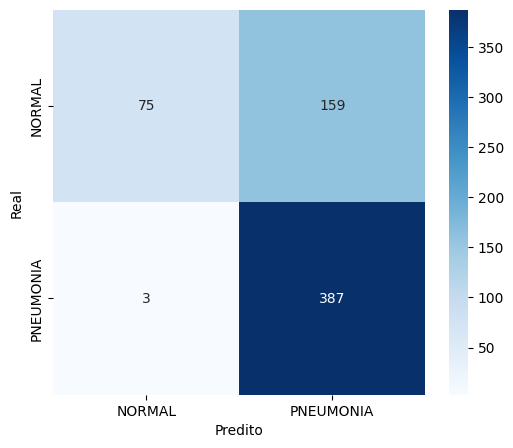

In [ ]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel('Predito')
plt.ylabel('Real')


plt.savefig(
    "/content/drive/MyDrive/pneumonia/Experimento_2/matriz_confusao_BaseLine.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

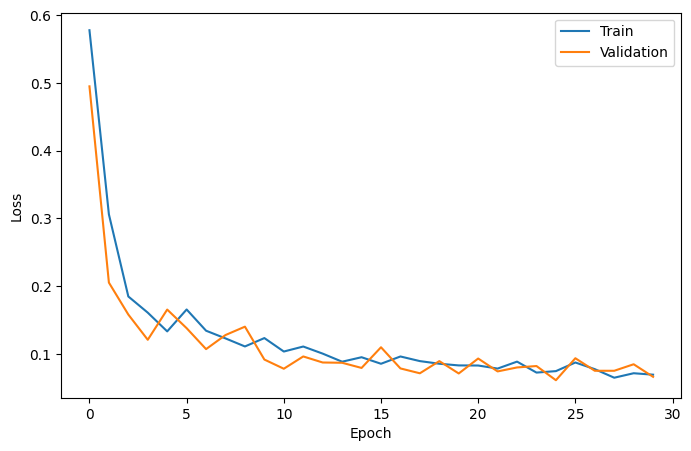

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label='Train')
plt.plot(val_losses,label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()


plt.savefig(
    "/content/drive/MyDrive/pneumonia/Experimento_2/loss_curve_BaseLine.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


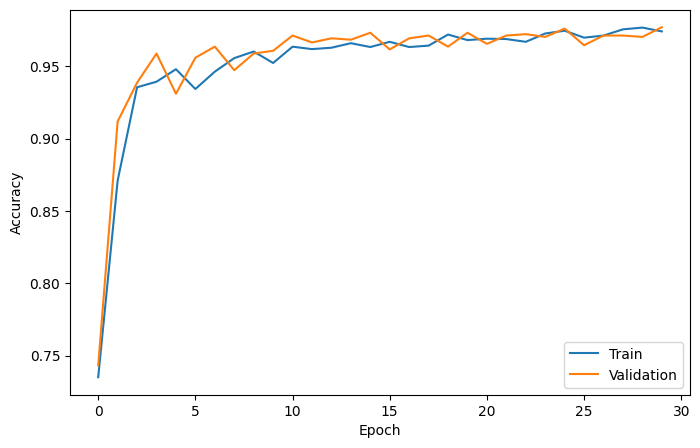

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accs,label='Train')
plt.plot(val_accs,label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.savefig(
    "/content/drive/MyDrive/pneumonia/Experimento_2/accuracy_curve_BaseLine.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()